**Writer's note:** Visualization을 제외하고 데이터셋을 구축하는 데 사용된 코드들은 이미 final_challengerset에는 적용된 코드이며, 여러 데이터셋을 겹치며 수정했기에 과정이 많이 복잡해진 관계로, 각 단계에 사용된 코드만 다시 정리한 점 참고 부탁드립니다.
## 1. challenger Cleaning

In [1]:
import pandas as pd
df = pd.read_csv('final_dataset_1.csv')

In [3]:
df.columns

Index(['thread_id', 'OP', 'post_date', 'post_id', 'post_score',
       'selftext_comment', 'title', 'thread_size', 'comment_depth', 'is_delta',
       'thread_pattern', 'ChallengerOP', 'comment_id', 'author', 'body',
       'comment_date', 'comment_score', 'processed_body', 'length_comment',
       'evidence_z_comment', 'intuition_z_comment',
       'evidence_minus_intuition_score_comment', 'Topic', 'Title',
       'Politicality', 'Hardness', 'Controversiality', 'length_post',
       'evidence_z_post', 'intuition_z_post',
       'evidence_minus_intuition_score_post', 'delta_ratio_c', 'year',
       'delta_ratio'],
      dtype='str')

### 1.1. Preprocessing

In [ ]:
import nltk
from nltk.corpus import stopwords
import string
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk.tag import pos_tag
from bs4 import BeautifulSoup # For more robust HTML/Markdown stripping if needed
import contractions # For expanding contractions like "don't" to "do not"
import emoji # For handling emojis
import time

# --- Download NLTK resources (if not already downloaded) ---
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger')
# --- Constants ---
STOP_WORDS = set(stopwords.words('english'))
# Add custom stopwords if needed, e.g., common Reddit/CMV terms
CUSTOM_STOP_WORDS = {"cmv", "op", "edit", "eta", "tldr", "dr", "tl", "selftext", "thread_body"}
STOP_WORDS.update(CUSTOM_STOP_WORDS)

LEMMATIZER = WordNetLemmatizer()
MIN_TOKENS_AFTER_PREPROCESSING = 5 # Filter out very short texts

### 1.2. Removing Quotes and URLs

In [ ]:
import re

def clean_thread_body_1(row):
    '''
    1. thread_body에서 '>'로 시작하고 '\n'으로 끝나는 모든 문자열을 찾습니다.
    2. 찾은 문자열이 selftext에 존재하는지 확인합니다.
    3. 존재한다면 thread_body에서 해당 문자열을 제거합니다.
    4. 최종적으로 수정된 thread_body를 반환합니다.
    '''
    thread_body_list = row['thread_body']
    selftext = row['selftext']
    
    cleaned_body =[]
    for comment in thread_body_list:
        # Find all substrings starting with '>' and ending with '\n'
        matches = re.findall(r'(>.*?\n\n)', comment)
        for match in matches:
            # Check if the match exists in selftext
            if isinstance(row['selftext'], str) and re.sub(r'[>\n]', '', match).strip() in selftext:
                # Remove the match from thread_body
                comment = comment.replace(match, '')
        cleaned_body.append(comment)

    return cleaned_body

def clean_thread_body_2(row):
    '''
    1. reference 텍스트 만들기: thread_body[:-1]
    2. thread_body에서 '>'로 시작하고 '\n'으로 끝나는 모든 문자열을 찾습니다.
    3. 찾은 문자열이 reference에 존재하는지 확인합니다.
    4. 존재한다면 thread_body에서 해당 문자열을 제거합니다.
    5. 최종적으로 수정된 thread_body를 반환합니다.
    '''
    thread_body_list = row['thread_body']
    
    # Iterate over a copy of the thread_body list to avoid modifying it while iterating
    cleaned_body = []
    for idx, comment in enumerate(thread_body_list):
        
        # Check if the sentence starts with '>' and ends with '\n\n'
        matches = re.findall(r'(>.*?\n\n)', comment)
        reference = thread_body_list[idx-1] if idx > 0 else None
        if reference:
            for match in matches:
                # Check if the match exists in the reference
                if re.sub(r'[>\n]', '', match).strip() in reference:
                    # Remove the match from thread_body
                    comment = comment.replace(match, '')
        cleaned_body.append(comment)

    return cleaned_body

def remove_urls(row): # 없애는 대신 <URL>로 바꿈
    thread_body_list = row['thread_body']
    url_pattern = r'(\(?https?://[^\s]+\)?)'
    cleaned_body = []

    for comment in thread_body_list:
        cleaned_body.append(re.sub(url_pattern, '<URL>', comment))

    return cleaned_body

# --- Helper function to convert NLTK POS tags to WordNet POS tags ---
def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith('J'):
        return nltk.corpus.wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return nltk.corpus.wordnet.VERB
    elif treebank_tag.startswith('N'):
        return nltk.corpus.wordnet.NOUN
    elif treebank_tag.startswith('R'):
        return nltk.corpus.wordnet.ADV
    else:
        return nltk.corpus.wordnet.NOUN # Default to noun

# --- Main Preprocessing Function ---
def preprocess_text(text):
    if not isinstance(text, str) or not text.strip():
        return ""

    # 2. Lowercasing
    text = text.lower()

    # 4. Markdown Stripping (Basic - for more complex, consider markdown library)
    # Remove bold/italics markers (keeping the content)
    text = re.sub(r'\*([^*]+)\*', r'\1', text) # Italics *text*
    text = re.sub(r'_([^_]+)_', r'\1', text) # Italics _text_
    text = re.sub(r'\*\*([^*]+)\*\*', r'\1', text) # Bold **text**
    text = re.sub(r'__([^_]+)__', r'\1', text) # Bold __text__
    text = re.sub(r'~~([^~]+)~~', r'\1', text) # Strikethrough
    # Remove list markers (keeping the content)
    text = re.sub(r'^\s*[\*\-\+]\s+', '', text, flags=re.MULTILINE) # Bullet points
    text = re.sub(r'^\s*\d+\.\s+', '', text, flags=re.MULTILINE) # Numbered lists
    # Remove heading markers
    text = re.sub(r'^#+\s*', '', text, flags=re.MULTILINE)
    # Remove spoiler tags >!text!< (keeping the content)
    text = re.sub(r'>!([^!<]+)!<', r'\1', text)


    # 5. User/Subreddit Mention Removal/Replacement
    text = re.sub(r'/u/\w+|u/\w+', '<USER>', text)
    text = re.sub(r'/r/\w+|r/\w+', '<SUBREDDIT>', text)

    # 6. Emoji Removal (or replacement with text description)
    text = emoji.replace_emoji(text, replace='') # Removes emojis

    # 7. Contraction Expansion
    text = contractions.fix(text)

    # 8. Punctuation Removal (keep apostrophes within words if not handled by contractions, but contractions.fix usually does)
    # string.punctuation already includes apostrophe. If contractions.fix is good, we can remove all.
    punct_to_remove = string.punctuation.replace("<", "").replace(">", "") # 토큰 그대로 두기 위함
    translator = str.maketrans('', '', punct_to_remove)
    text = text.translate(translator)

    # 9. Number Removal/Replacement
    text = re.sub(r'\b\d+\b', '<NUM>', text) # Replaces standalone numbers

    # Change abbreviations to full forms
    abbreviations = {
        r'\bAITA\b': 'Am I the Asshole',
        r'\bYTA\b': 'You are the Asshole',
        r'\bNTA\b': 'Not the Asshole',
        r'\bIMO\b': 'In my opinion',
        r'\bIMHO\b': 'In my humble opinion'
    }
    for abbr, full in abbreviations.items():
        text = re.sub(abbr, full, text, flags=re.IGNORECASE)

    # 10. Tokenization
    tokens = word_tokenize(text)

    # 11. Stopword Removal
    tokens = [word for word in tokens if word not in STOP_WORDS and len(word) > 1] # also remove single char tokens

    # 12. Lemmatization (with POS tagging for better accuracy)
    pos_tags = pos_tag(tokens)
    lemmatized_tokens = [LEMMATIZER.lemmatize(word, get_wordnet_pos(pos)) for word, pos in pos_tags]

    # Filter out if too few tokens remain
    if len(lemmatized_tokens) < MIN_TOKENS_AFTER_PREPROCESSING:
        return ""

    # 13. Rejoin tokens and remove extra whitespace
    processed_text = " ".join(lemmatized_tokens).strip()
    processed_text = re.sub(r'\s+', ' ', processed_text) # Normalize multiple spaces to one

    return processed_text

In [ ]:
# 텍스트 처리를 위해 selftext가 null이면 제거
df.dropna(subset='selftext', inplace=True)

# post와 thread_id별로 묶어야 quote가 있는지 확인 가능하기 때문에 그룹화. 그 이후 다시 explode.
grouped_body = df.groupby('thread_id')['body'].apply(list)
grouped_id = df.groupby('thread_id')['comment_id'].apply(list)
grouped_body_df = grouped_body.to_frame().reset_index()
grouped_id = grouped_id.to_frame().reset_index()
grouped_body_df = grouped_body_df.merge(df[['thread_id', 'selftext']], on='thread_id', how='left')
grouped_body_df = grouped_body_df.merge(grouped_id, on='thread_id', how='left')
cache = grouped_body_df.drop_duplicates('thread_id')

cache['body'] = cache.apply(clean_thread_body_1, axis=1)
cache['body'] = cache.apply(clean_thread_body_2, axis=1)
cache['body'] = cache.apply(remove_urls, axis=1)
cache = cache.explode(['body', 'comment_id'])

from tqdm import tqdm
df = df.merge(cache[['comment_id', 'body']], how='left', on='comment_id')
df['processed_body'] = [preprocess_text(x) for x in tqdm(df['body_y'], desc="Preprocessing body_y")]
df.drop('body_y', axis=1, inplace=True)

## 2. Training Word2Vec Model

In [ ]:
# challenger의 댓글만 선택
train = df[df['ChallengerOP']=='C']
train.dropna(subset='processed_body', inplace=True)

In [ ]:
from gensim.models import Word2Vec
from gensim.models.callbacks import CallbackAny2Vec
import contextlib
import io
import sys
import time
from tqdm import tqdm

class EpochLogger(CallbackAny2Vec):
    def __init__(self):
        self.epoch = 0
        self.start_time = time.time()

    def on_epoch_begin(self, model):
        print(f"Epoch #{self.epoch + 1} 시작")

    def on_epoch_end(self, model):
        elapsed = time.time() - self.start_time
        print(f"Epoch #{self.epoch + 1} 종료 - 누적 시간: {elapsed:.2f}초")
        self.epoch += 1


class FilteredStderr(io.TextIOBase):
    def __init__(self, base_stream, blocked_messages):
        self.base_stream = base_stream
        self.blocked_messages = tuple(blocked_messages)

    def write(self, text):
        if any(msg in text for msg in self.blocked_messages):
            return len(text)
        return self.base_stream.write(text)

    def flush(self):
        self.base_stream.flush()


# 문장을 generator로 반환하는 iterable 클래스
class MySentences:
    def __init__(self, texts):
        self.texts = texts

    def __iter__(self):
        # tqdm을 stdout으로 보내면 stderr 필터링과 독립적으로 진행률 표시를 유지할 수 있음
        for line in tqdm(self.texts, desc="Streaming", file=sys.stdout):
            yield line.split()


sentences = MySentences(train['processed_body'])

filtered_stderr = FilteredStderr(
    sys.stderr,
    blocked_messages=["Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'"]
)

with contextlib.redirect_stderr(filtered_stderr):
    w2v_model = Word2Vec(
        sentences=sentences,
        vector_size=300,      # 논문 기준
        window=5,
        min_count=10,         # 최소 등장 횟수 설정
        workers=8,            # 병렬 처리
        sg=1,                 # skip-gram 방식 사용
        epochs=10,
        callbacks=[EpochLogger()]
    )

# 모델 저장
w2v_model.save("word2vec_0728.model")



In [ ]:
import os
import torch
import torch.nn as nn
from gensim.models import Word2Vec
from sentence_transformers import SentenceTransformer
from sentence_transformers.models import Pooling
from typing import List


# 1. Custom Word2Vec Embedding 모듈 정의
class WordEmbeddings(nn.Module):
    def __init__(self, word_vectors=None):
        super().__init__()
        if word_vectors is not None:
            self.word2idx = {word: idx for idx, word in enumerate(word_vectors.index_to_key)}
            self.idx2word = word_vectors.index_to_key
            self.embedding = nn.Embedding.from_pretrained(
                embeddings=torch.tensor(word_vectors.vectors), freeze=True
            )
        else:
            self.word2idx = {}
            self.idx2word = []
            self.embedding = None

    def forward(self, features):
        sentences = features['text']
        batch_indices = []
        max_len = 0

        # 토큰 인덱스 변환 및 최대 길이 계산
        for sentence in sentences:
            tokens = sentence.strip().split()
            indices = [self.word2idx.get(token, 0) for token in tokens]
            batch_indices.append(indices)
            if len(indices) > max_len:
                max_len = len(indices)

        # 패딩
        padded_indices = []
        attention_masks = []
        for indices in batch_indices:
            pad_len = max_len - len(indices)
            padded = indices + [0] * pad_len
            mask = [1] * len(indices) + [0] * pad_len
            padded_indices.append(padded)
            attention_masks.append(mask)

        indices_tensor = torch.tensor(padded_indices, dtype=torch.long)  # (batch, max_len)
        emb = self.embedding(indices_tensor)           # (batch, max_len, dim)
        features['token_embeddings'] = emb
        features['attention_mask'] = torch.tensor(attention_masks)
        return features

    def tokenize(self, texts):
        return {'text': texts}

    def get_word_embedding_dimension(self):
        return self.embedding.embedding_dim

    def save(self, output_path):
        os.makedirs(output_path, exist_ok=True)
        with open(os.path.join(output_path, 'vocab.txt'), 'w', encoding='utf-8') as f:
            for word in self.idx2word:
                f.write(f"{word}\n")
        torch.save(self.embedding.state_dict(), os.path.join(output_path, 'embeddings.pt'))

    def load(self, input_path):
        with open(os.path.join(input_path, 'vocab.txt'), 'r', encoding='utf-8') as f:
            self.idx2word = [line.strip() for line in f]
            self.word2idx = {word: idx for idx, word in enumerate(self.idx2word)}
        weight = torch.load(os.path.join(input_path, 'embeddings.pt'))
        self.embedding = nn.Embedding(len(self.idx2word), weight['weight'].shape[1])
        self.embedding.load_state_dict(weight)
        self.embedding.weight.requires_grad = False

# 3. WordEmbeddings 모듈 생성
word_vectors = w2v_model.wv
word_embedding_model = WordEmbeddings(word_vectors)

# 4. Pooling 구성
pooling_model = Pooling(word_embedding_model.get_word_embedding_dimension(), pooling_mode_mean_tokens=True)

# 5. SentenceTransformer 모델 통합
model = SentenceTransformer(modules=[word_embedding_model, pooling_model])

## 3. Calculating evidence and intuition scores
comments뿐만 아니라 post에도 적용되었으나 'post' 점수를 계산하는 코드는 포함되지 않음.

In [ ]:
evidence_keywords = [
    "accurate", "exact", "intelligence", "precise", "search",
    "analyse", "examination", "investigate", "procedure", "show",
    "analysis", "examine", "investigation", "process", "statistics",
    "correct", "expert", "knowledge", "proof", "study",
    "correction", "explore", "lab", "question", "trial",
    "data", "fact", "learn", "read", "real",
    "dossier", "find", "logic", "reason", "true",
    "education", "findings", "logical", "research", "truth",
    "evidence", "information", "method", "science", "truthful",
    "evident", "inquiry", "pinpoint", "scientific"
]

intuition_keywords = [
    "advice", "doubt", "mislead", "suggestion",
    "belief", "fake", "mistaken", "suspicion",
    "believe", "fake news", "mistrust", "view",
    "bogus", "feeling", "opinion", "viewpoint",
    "common sense", "genuine", "perspective", "wrong",
    "deceive", "guess", "phony",
    "deception", "gut", "point of view",
    "dishonest", "instinct", "propaganda",
    "dishonesty", "intuition", "sense",
    "distrust", "lie", "suggest"
]

from sentence_transformers import SentenceTransformer, util, models
import matplotlib.pyplot as plt
import sys
import re
import pickle
import argparse
import numpy as np
import pandas as pd
from tqdm import tqdm
import torch
from scipy.stats import zscore

device = 'mps' if torch.cuda.is_available() else 'cpu'
model.to(device)

def get_embeddings(text, model):
    #model = SentenceTransformer(model_name_or_path)
    #encode text in batches 
    corpus_embeddings = model.encode(text, batch_size=1024, show_progress_bar=True, convert_to_tensor=True)
    assert len(corpus_embeddings) == len(text)
    return corpus_embeddings

def length_adjustment_bin(df, length_column='length', minimum_length=10):
    bins = range(0, df[length_column].max()+minimum_length, minimum_length)
    df[f'{length_column}_bin'] = pd.cut(df[length_column], bins=bins,)
    df['evidence_mean'] = df.groupby(f'{length_column}_bin')['avg_evidence_score'].transform('mean')
    df['evidence_adj'] = df['avg_evidence_score'] - df['evidence_mean']

    df['intuition_mean'] = df.groupby(f'{length_column}_bin')['avg_intuition_score'].transform('mean')
    df['intuition_adj'] = df['avg_intuition_score'] - df['intuition_mean']
    return df

def evidence_minus_intuition_score(df, evidence_column='evidence_adj', intuition_column='intuition_adj'):
    df[['evidence_z', 'intuition_z']] = df[[evidence_column, intuition_column]].apply(zscore)
    df['evidence_minus_intuition_score'] = df['evidence_z'] - df['intuition_z']
    return df

evidence_sim = torch.Tensor()
intuition_sim = torch.Tensor()
chunk_size = 200000
list_df = [df[idx:idx+chunk_size] for idx in range(0, len(df), chunk_size)]

for batch in list_df:
    batch_text = batch['processed_body']
    batch_text = list(batch_text)
    text_embeddings = get_embeddings(batch_text, model)        

    evidence_embeddings = get_embeddings(evidence_keywords, model)
    evidence_embeddings = torch.mean(evidence_embeddings, dim=0)

    intuition_embeddings = get_embeddings(intuition_keywords, model)
    intuition_embeddings = torch.mean(intuition_embeddings, dim=0)

    evidence_sim = torch.cat((evidence_sim, util.cos_sim(text_embeddings, evidence_embeddings).cpu()), 0)
    intuition_sim = torch.cat((intuition_sim, util.cos_sim(text_embeddings, intuition_embeddings).cpu()), 0)

avg_evidence_score = np.average(evidence_sim.cpu().numpy(), axis=1)  
avg_intuition_score = np.average(intuition_sim.cpu().numpy(), axis=1)  
df['avg_evidence_score'] = avg_evidence_score
df['avg_intuition_score'] = avg_intuition_score

df['length'] = df['processed_body'].apply(lambda x: len(x.split()))
df = length_adjustment_bin(df=df)
df = evidence_minus_intuition_score(df, evidence_column='evidence_adj', intuition_column='intuition_adj')
df.drop(columns=['length_bin','evidence_mean','intuition_mean', 'evidence_adj','intuition_adj'], inplace=True)

## 4. Statistical Analysis

In [7]:
df.head()

,thread_id,OP,post_date,post_id,post_score,selftext_comment,title,thread_size,comment_depth,is_delta,...,Politicality,Hardness,Controversiality,length_post,evidence_z_post,intuition_z_post,evidence_minus_intuition_score_post,delta_ratio_c,year,delta_ratio
0,67aa45630bc679138fd9f024,RealHonestJohn,1358439851,16ra7x,9,"proof: overpopulation, religion, wasting resou...","CMV I think humanity is selfish, stupid, and s...",1.0,1,0,...,0,1,2,16,-0.483931,-1.056064,0.572133,0.000,2013,0.0
1,67aa45630bc679138fd9f026,RealHonestJohn,1358439851,16ra7x,9,"proof: overpopulation, religion, wasting resou...","CMV I think humanity is selfish, stupid, and s...",1.0,1,0,...,0,1,2,16,-0.483931,-1.056064,0.572133,0.000,2013,0.0
2,67aa45630bc679138fd9f027,RealHonestJohn,1358439851,16ra7x,9,"proof: overpopulation, religion, wasting resou...","CMV I think humanity is selfish, stupid, and s...",1.0,1,0,...,0,1,2,16,-0.483931,-1.056064,0.572133,0.000,2013,0.0
3,67aa45630bc679138fd9f029,RealHonestJohn,1358439851,16ra7x,9,"proof: overpopulation, religion, wasting resou...","CMV I think humanity is selfish, stupid, and s...",1.0,1,0,...,0,1,2,16,-0.483931,-1.056064,0.572133,0.125,2013,0.0
4,67aa45630bc679138fd9f02b,ancillarynipple,1358440202,16ralh,14,Why should I pay higher taxes when I use less ...,I think single people should get the most tax ...,4.0,1,0,...,1,1,1,12,-0.409995,-0.612117,0.202123,0.000,2013,0.0


In [6]:
challenger = df[df['ChallengerOP']=='C']

### Level 1 model

In [ ]:
import statsmodels.formula.api as smf

formula = """
    is_delta
    ~ evidence_z_comment + intuition_z_comment + Politicality
    + delta_ratio + delta_ratio_c + thread_size + comment_depth + comment_score
"""

model = smf.logit(formula, data=challenger).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.129557
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:               is_delta   No. Observations:              1629144
Model:                          Logit   Df Residuals:                  1629124
Method:                           MLE   Df Model:                           19
Date:                Fri, 19 Dec 2025   Pseudo R-squ.:                  0.3878
Time:                        00:27:50   Log-Likelihood:            -2.1107e+05
converged:                       True   LL-Null:                   -3.4478e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              -5.2438      0.028   -189.269      0.000      -5.298      -5.189
C(

### Level 2 model

In [ ]:
formula = """
    is_delta
    ~ evidence_z_comment * evidence_z_post + intuition_z_comment * evidence_z_post +
    evidence_z_comment * intuition_z_post + intuition_z_comment * intuition_z_post
    + Politicality + delta_ratio + delta_ratio_c + thread_size + comment_depth + comment_score + C(year)
"""

model = smf.logit(formula, data=challenger).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.129518
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:               is_delta   No. Observations:              1629144
Model:                          Logit   Df Residuals:                  1629118
Method:                           MLE   Df Model:                           25
Date:                Fri, 19 Dec 2025   Pseudo R-squ.:                  0.3880
Time:                        00:28:13   Log-Likelihood:            -2.1100e+05
converged:                       True   LL-Null:                   -3.4478e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
Intercept                               -5.2701      0.0

### Level 3 model

In [ ]:
formula = """
    is_delta
    ~ evidence_z_comment * evidence_z_post + intuition_z_comment * evidence_z_post +
    evidence_z_comment * intuition_z_post + intuition_z_comment * intuition_z_post
    + evidence_z_comment * Politicality + intuition_z_comment * Politicality 
    + delta_ratio + delta_ratio_c + thread_size + comment_depth + comment_score + C(year)
"""

model = smf.logit(formula, data=challenger).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.129513
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:               is_delta   No. Observations:              1629144
Model:                          Logit   Df Residuals:                  1629116
Method:                           MLE   Df Model:                           27
Date:                Fri, 19 Dec 2025   Pseudo R-squ.:                  0.3880
Time:                        00:28:23   Log-Likelihood:            -2.1099e+05
converged:                       True   LL-Null:                   -3.4478e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
Intercept                               -5.2696      0.0

In [8]:
import statsmodels.formula.api as smf
formula = """
    is_delta
    ~ evidence_z_comment * evidence_z_post + intuition_z_comment * evidence_z_post +
    evidence_z_comment * intuition_z_post + intuition_z_comment * intuition_z_post
    + evidence_z_comment * Politicality + intuition_z_comment * Politicality 
    + thread_size + comment_depth + comment_score + C(year)
"""

model = smf.logit(formula, data=challenger).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.186397
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:               is_delta   No. Observations:              1629144
Model:                          Logit   Df Residuals:                  1629118
Method:                           MLE   Df Model:                           25
Date:                Thu, 26 Mar 2026   Pseudo R-squ.:                  0.1192
Time:                        13:53:46   Log-Likelihood:            -3.0367e+05
converged:                       True   LL-Null:                   -3.4478e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
Intercept                               -3.7363      0.0

## 5. Visualization

/var/folders/g2/j70lmnjx7r338m_8lsfpyd440000gn/T/ipykernel_62931/1175153280.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  challenger['quarter'] = pd.to_datetime(challenger['comment_date'], unit='s').dt.to_period('Q')
/var/folders/g2/j70lmnjx7r338m_8lsfpyd440000gn/T/ipykernel_62931/1175153280.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  challenger['month'] = pd.to_datetime(challenger['comment_date'], unit='s').dt.to_period('M')


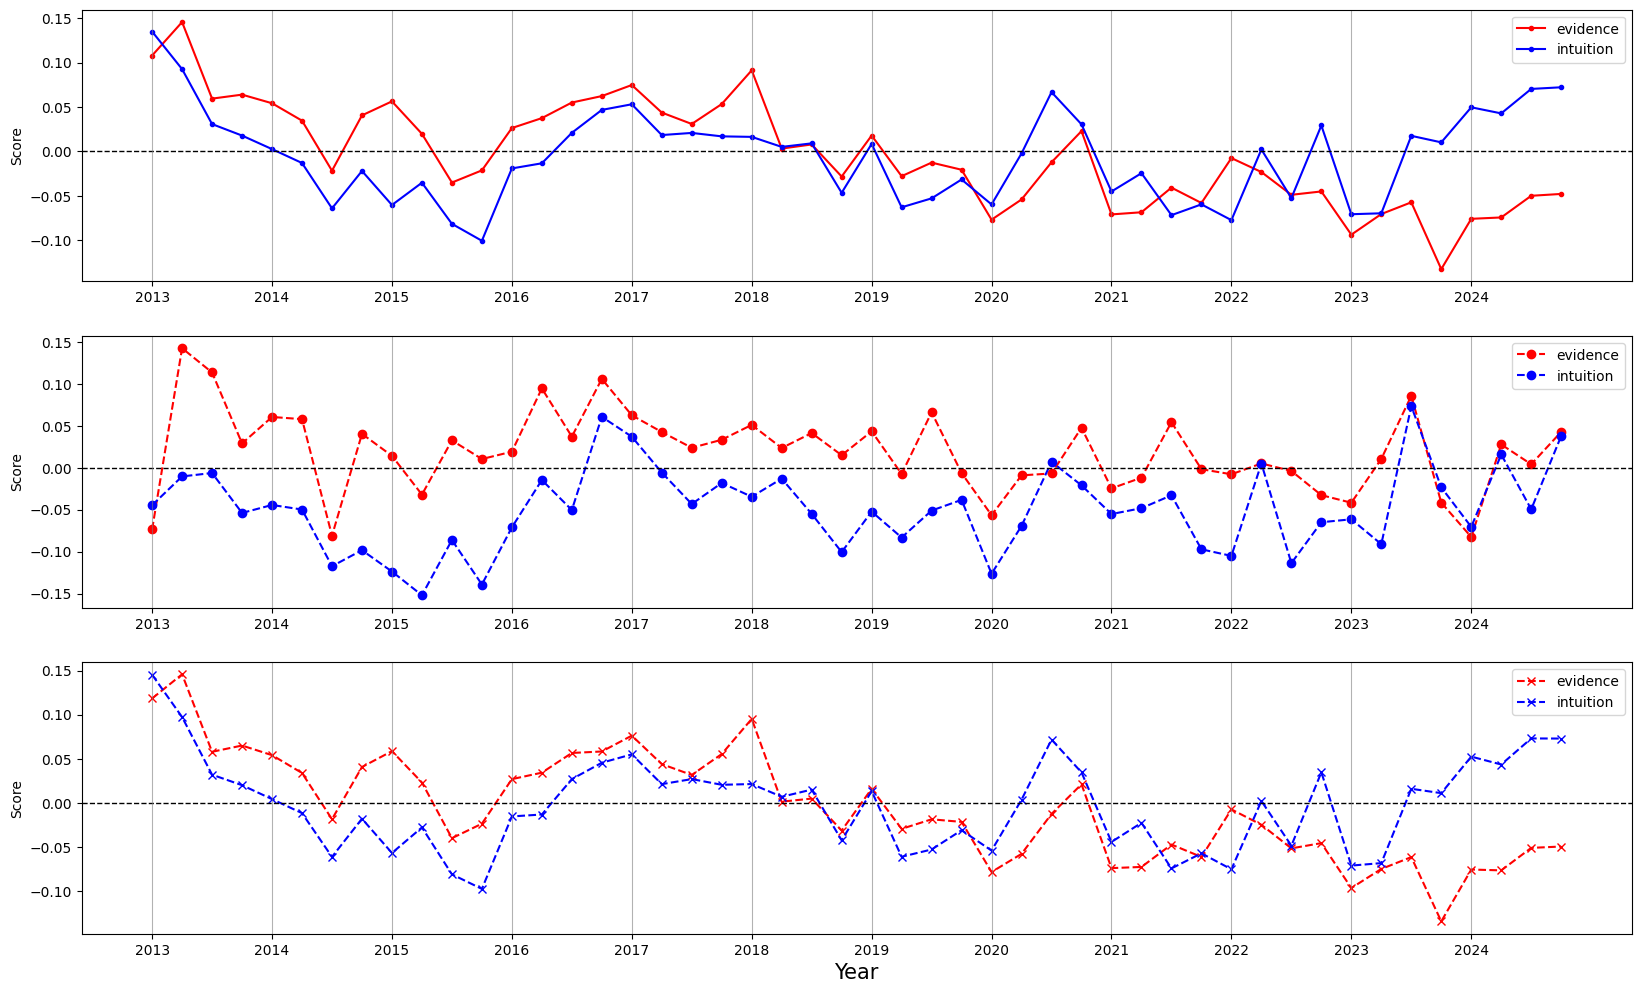

In [14]:
# ...existing code...
import matplotlib.pyplot as plt

challenger['quarter'] = pd.to_datetime(challenger['comment_date'], unit='s').dt.to_period('Q')
challenger['month'] = pd.to_datetime(challenger['comment_date'], unit='s').dt.to_period('M')

# Prepare series
evidence = challenger.groupby('quarter')['evidence_z_comment'].mean()
intuition = challenger.groupby('quarter')['intuition_z_comment'].mean()

# x ticks (연도 단위 레이블)
quarters = evidence.index
tick_pos = []
tick_labels = []
prev_year = None
for i, q in enumerate(quarters):
    if q.year != prev_year:
        tick_pos.append(i)
        tick_labels.append(str(q.year))
        prev_year = q.year

# 그리기 (subplots + 서브플롯 레이블 a,b,c 추가)
fig, axes = plt.subplots(3, 1, figsize=(20, 12), sharex=True)

# (a) whole challenger
axes[0].plot(range(len(evidence)), evidence.values, marker='.', linestyle='-', color='r')
axes[0].plot(range(len(intuition)), intuition.values, marker='.', linestyle='-', color='b')
axes[0].axhline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_ylabel('Score')
axes[0].legend(['evidence', 'intuition'])
#axes[0].text(0.005, 0.95, '(a)', transform=axes[0].transAxes, fontsize=20, fontweight='bold', va='top')

# (b) delta only
challenger_delta = challenger[challenger['is_delta'] == 1]
evidence_d = challenger_delta.groupby('quarter')['evidence_z_comment'].mean()
intuition_d = challenger_delta.groupby('quarter')['intuition_z_comment'].mean()
axes[1].plot(range(len(evidence_d)), evidence_d.values, marker='o', linestyle='--', color='r')
axes[1].plot(range(len(intuition_d)), intuition_d.values, marker='o', linestyle='--', color='b')
axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_ylabel('Score')
axes[1].legend(['evidence', 'intuition'])
#axes[1].text(0.005, 0.95, '(b)', transform=axes[1].transAxes, fontsize=20, fontweight='bold', va='top')

# (c) non-delta only
challenger_nondelta = challenger[challenger['is_delta'] == 0]
evidence_nd = challenger_nondelta.groupby('quarter')['evidence_z_comment'].mean()
intuition_nd = challenger_nondelta.groupby('quarter')['intuition_z_comment'].mean()
axes[2].plot(range(len(evidence_nd)), evidence_nd.values, marker='x', linestyle='--', color='r')
axes[2].plot(range(len(intuition_nd)), intuition_nd.values, marker='x', linestyle='--', color='b')
axes[2].axhline(0, color='black', linestyle='--', linewidth=1)
axes[2].set_xlabel('Year', fontsize=15)
axes[2].set_ylabel('Score')
axes[2].legend(['evidence', 'intuition'])
#axes[2].text(0.005, 0.95, '(c)', transform=axes[2].transAxes, fontsize=20, fontweight='bold', va='top')

# 연도 경계에 수직선 추가 (첫 번째 연도 시작은 제외)
for ax in axes:
    for pos in tick_pos:
        ax.axvline(x=pos - 0.0, color='gray', linestyle='-', linewidth=0.8, alpha=0.6)

# 모든 서브플롯에 연도 레이블 표시
for ax in axes:
    ax.set_xticks(tick_pos)
    ax.set_xticklabels(tick_labels, fontsize=10)
    ax.tick_params(axis='x', labelbottom=True)  # sharex=True여도 하단 레이블만 기본 표시되므로 강제로 켬

# 서브플롯 간 간격 늘리기
fig.subplots_adjust(hspace=0.2)
#plt.tight_layout()
plt.show()
# ...existing code...

In [15]:
total = challenger.groupby('quarter')['comment_id'].count()
delta = challenger[challenger['is_delta']==1].groupby('quarter')['comment_id'].count()
thread_size = challenger.drop_duplicates('thread_id').groupby('quarter')['thread_size'].mean()
karma = challenger.groupby('quarter')['comment_score'].mean()
post = challenger.drop_duplicates('thread_id').groupby('quarter')['thread_id'].count()
post_political = challenger.drop_duplicates('thread_id').groupby('quarter')['Politicality'].sum()

In [17]:
total_thread = challenger.drop_duplicates('thread_id').groupby('quarter')['thread_id'].count()
delta_thread = challenger[challenger['is_delta']==1].drop_duplicates('thread_id').groupby('quarter')['thread_id'].count()

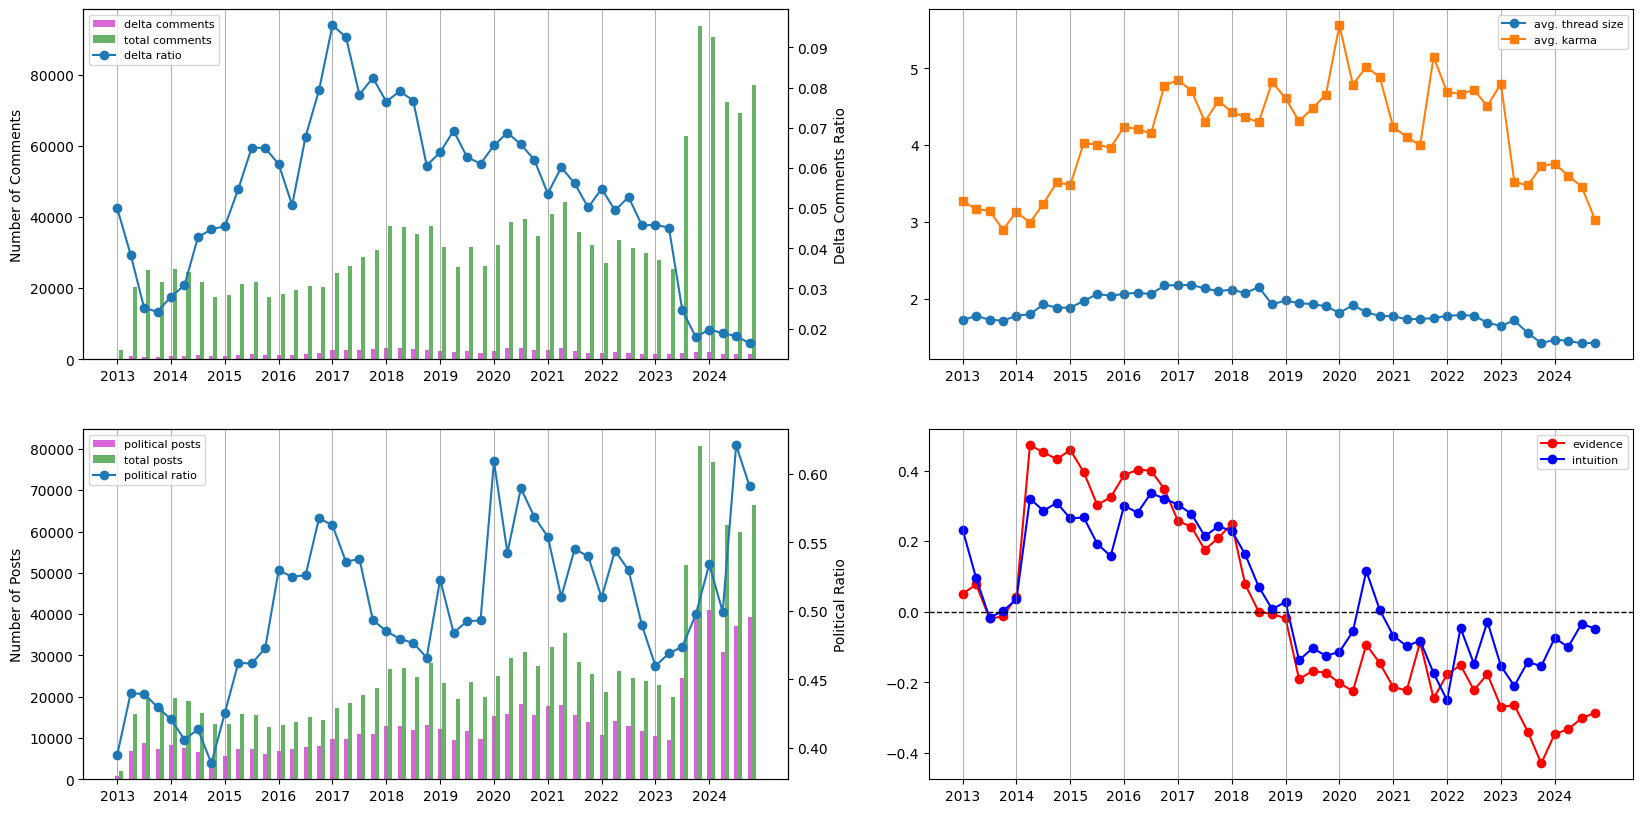

In [18]:
# ...existing code...
import matplotlib.pyplot as plt
import numpy as np

# x ticks (연도 단위 레이블)
quarters = evidence.index
tick_pos = []
tick_labels = []
prev_year = None
for i, q in enumerate(quarters):
    if q.year != prev_year:
        tick_pos.append(i)
        tick_labels.append(str(q.year))
        prev_year = q.year

index = np.arange(len(total))
bar_width = 0.3

# 그리기 (subplots + 서브플롯 레이블 a,b,c 추가)
fig, axes = plt.subplots(2, 2, figsize=(20, 10), sharex=True)

# (a) whole data -> # of comments & delta
a3 = axes[0,0].bar(index, delta.values, bar_width, alpha=0.6, label='delta comments', color='m')
a4 = axes[0,0].bar(index+bar_width, total.values, bar_width, alpha=0.6, label='total comments', color='g')
ax1 = axes[0,0].twinx()
l1 = ax1.plot(index, (delta_thread/total_thread).values, marker='o', label='delta ratio')
axes[0,0].set_ylabel('Number of Comments')
ax1.set_ylabel('Delta Comments Ratio')
plots = [a3, a4, l1[0]]
labels = [p.get_label() for p in plots]
axes[0,0].legend(plots, labels, loc='upper left', fontsize=8)
#axes[0,0].text(0.005, 0.98, '(a)', transform=axes[0,0].transAxes, fontsize=20, fontweight='bold', va='top')

# (b) comments statistics -> avg. thread size & karma

#b1 = axes[1].bar(index, (delta / total).values, bar_width, alpha=0.6, color='orange',label='delta comments')
#axes[1].set_ylabel('Delta Comments Ratio')

#ax2 = axes[1].twinx()
b2 = axes[0,1].plot(index, thread_size.values, marker='o',  label='avg. thread size')
b3 = axes[0,1].plot(index, karma.values, marker='s', label='avg. karma')
#axes[1].set_ylabel('Average Thread Size / Karma')
axes[0,1].legend(loc='upper right', fontsize=8)

# x축 위치를 정 가운데로 조정하고 x축의 텍스트를 year 정보와 매칭
#plots = [b1, b2[0], b3[0]]
#labels = [p.get_label() for p in plots]
#axes[1].set_xlabel('Year', fontsize=15)
#axes[1].legend(plots, labels, loc='upper right', fontsize=8)
#axes[0,1].text(0.005, 0.98, '(b)', transform=axes[0,1].transAxes, fontsize=20, fontweight='bold', va='top')

# (c) posts statistics -> total posts & political posts & ratio
b3 = axes[1,0].bar(index, post_political.values, bar_width, color='m', alpha=0.6, label='political posts')
b2 = axes[1,0].bar(index+bar_width, post.values, bar_width, color='g', alpha=0.6, label='total posts')
axes[1,0].set_ylabel('Number of Posts')
ax3 = axes[1,0].twinx()
l2 = ax3.plot(index, (post_political/post).values, marker='o', label='political ratio')
ax3.set_ylabel('Political Ratio')

plots = [b3, b2, l2[0]]
labels = [p.get_label() for p in plots]
#|axes[1,0].set_xlabel('Year', fontsize=15)
axes[1,0].legend(plots, labels, loc='upper left',fontsize=8)
#axes[1,0].text(0.005, 0.98, '(c)', transform=axes[1,0].transAxes, fontsize=20, fontweight='bold', va='top')

# (d) post E & I 따로
evidence = challenger.drop_duplicates('thread_id').groupby('quarter')['evidence_z_post'].mean()
intuition = challenger.drop_duplicates('thread_id').groupby('quarter')['intuition_z_post'].mean()
l1 = axes[1,1].plot(range(len(evidence)), evidence.values, marker='o', linestyle='-', color='r', label='evidence')
l2 = axes[1,1].plot(range(len(intuition)), intuition.values, marker='o', linestyle='-', color='b', label='intuition')
axes[1,1].legend(loc='upper right', fontsize=8)
#axes[1,1].set_xlabel('Year', fontsize=15)
#axes[1,1].set_ylabel('Average Post Score')
axes[1,1].axhline(0, color='black', linestyle='--', linewidth=1)
#axes[1,1].text(0.005, 0.98, '(d)', transform=axes[1,1].transAxes, fontsize=20, fontweight='bold', va='top')

# 연도 경계에 수직선 추가 (첫 번째 연도 시작은 제외)
for ax in axes.flatten():            # 2x2 배열 대응: flatten() 사용
    for pos in tick_pos:
        ax.axvline(x=pos, color='gray', linestyle='-', linewidth=0.8, alpha=0.6)

# 모든 서브플롯에 연도 레이블 표시
for ax in axes.flatten():
    ax.set_xticks(tick_pos)
    ax.set_xticklabels(tick_labels, fontsize=10)
    ax.tick_params(axis='x', labelbottom=True)  # sharex=True여도 하단 레이블만 기본 표시되므로 강제로 켬

# 서브플롯 간 간격 늘리기
fig.subplots_adjust(hspace=0.2)
#plt.tight_layout()
plt.show()